# Notebook 1 — Baseline Dataset Preparation and Real-Data Classifier

**Purpose**
Establishes the fixed data foundation used throughout the entire study: a real-data train/test split and a baseline classifier trained exclusively on real defect images. Every subsequent experiment in Notebooks 2 and 3 is evaluated against the held-out test set created here.

**What this notebook accomplishes**
1. Downloads the MVTec AD `metal_nut` category
2. Verifies the downloaded data against expected counts before proceeding
3. Constructs a fixed, reproducible train/test split (seeded), simplified to a binary good/defective classification problem
4. Trains a ResNet18 classifier on real data only, establishing the study's baseline reference point
5. Evaluates the baseline using escape rate and false rejection rate, in addition to accuracy

**Inputs**
None — this notebook downloads its own data from a public Hugging Face mirror of MVTec AD.

**Outputs**
- `data_split.json` — the fixed train/test split, required by Notebooks 2 and 3
- `baseline_model.pt` — trained baseline model weights
- `baseline_results.json` — baseline accuracy, escape rate, and false rejection rate

**Role in the overall study**
This notebook defines the ground truth against which every later experiment is measured. The test set fixed here is never altered or regenerated in Notebooks 2 or 3.

## Step 0 — Environment Setup

Installs the libraries required for data handling, model training, and evaluation:

- `torch`, `torchvision` — model construction and training
- `Pillow` — image I/O
- `scikit-learn` — confusion matrix and accuracy computation
- `pandas` — result tabulation
- `matplotlib` — visualization

In [ ]:
!pip install -q torch torchvision pillow scikit-learn pandas matplotlib seaborn

## Step 1 — Dataset Acquisition

Downloads the MVTec AD `metal_nut` category from a Hugging Face mirror that preserves the original train/test split structure. The official MVTec AD download endpoint has been unreliable; the mirror used here was verified to provide a complete train/test split prior to use.

In [ ]:
import os
from pathlib import Path

!pip install -q datasets
from datasets import load_dataset

CATEGORY = "metal_nut"
base_path = f"/content/{CATEGORY}"

print("Downloading MVTec AD metal_nut train split (good images only)...")
train_ds = load_dataset("TheoM55/mvtec_all_objects_split", split=f"{CATEGORY}.train")
print(f"  -> {len(train_ds)} training images (should be ~220 for metal_nut)")

print("Downloading MVTec AD metal_nut test split (good + all defect types)...")
test_ds = load_dataset("TheoM55/mvtec_all_objects_split", split=f"{CATEGORY}.test")
print(f"  -> {len(test_ds)} test images (mix of good + scratch + bent + color + flip)")

# Persist train images to local disk under a known, fixed directory structure so
# downstream cells and later notebooks can locate files by category without depending
# on how the source dataset happens to organize its internal splits.
train_good_dir = Path(base_path) / "train" / "good"
train_good_dir.mkdir(parents=True, exist_ok=True)
for i, sample in enumerate(train_ds):
    sample["image_path"].save(train_good_dir / f"{i:03d}.png")
print(f"Saved {len(train_ds)} images to {train_good_dir}")

# Organize test images by defect type at save time, since defect-type membership is required
# later to build the binary good/defective split and to isolate scratch-only data in Notebook 2.
counts = {}
for sample in test_ds:
    defect = sample["defect"]  # category label: 'good', 'scratch', 'bent', 'color', or 'flip'
    counts[defect] = counts.get(defect, 0) + 1
    idx = counts[defect]
    test_dir = Path(base_path) / "test" / defect
    test_dir.mkdir(parents=True, exist_ok=True)
    sample["image_path"].save(test_dir / f"{idx:03d}.png")

print("\nTest images saved by defect type:")
for defect, count in counts.items():
    print(f"  {defect}: {count} images")

print(f"\nbase_path is set to: {base_path}")

**Verification check.** The download cell above should report a `train` count near 220 and a `good` count under `test` near 22, consistent with published MVTec metal_nut statistics. A near-zero `train` count indicates an incomplete download; re-run the cell above or proceed to the backup method before continuing.

In [ ]:
# Verify file counts before proceeding - silently training on an incomplete or empty
# dataset produces results that look valid but are meaningless.
import glob

checks = {
    'train/good': f'{base_path}/train/good',
    'test/good': f'{base_path}/test/good',
    'test/scratch': f'{base_path}/test/scratch',
    'test/bent': f'{base_path}/test/bent',
}

all_good = True
for label, folder in checks.items():
    n = len(glob.glob(f'{folder}/*.png'))
    status = "OK" if n > 0 else "MISSING/EMPTY"
    print(f"{label}: {n} images [{status}]")
    if n == 0:
        all_good = False

if not all_good:
    print("\nSomething is missing - run the BACKUP METHOD cell below before continuing.")
else:
    print("\nAll good - continue to Step 3.")

train/good: 220 images [OK]
test/good: 22 images [OK]
test/scratch: 23 images [OK]
test/bent: 25 images [OK]

All good - continue to Step 3.


**Backup data source.** Used only if the verification above reports `MISSING/EMPTY` for `train/good`. Downloads the official MVTec metal_nut archive directly as a fallback if the primary mirror is incomplete.

In [ ]:
# Executes only if the primary download left train/good empty - guards against
# re-downloading unnecessarily when the primary source already succeeded.
import os

train_good_count = len(glob.glob(f'{base_path}/train/good/*.png'))

if train_good_count == 0:
    print("train/good is empty - attempting direct download from MVTec's server as a fallback...")
    if not os.path.exists('/content/metal_nut_official'):
        !wget -q "https://www.mydrive.ch/shares/38536/3830184030e49fe74747669442f0f282/download/420938129-1629951595/metal_nut.tar.xz" -O metal_nut.tar.xz
        !file metal_nut.tar.xz
        !ls -lh metal_nut.tar.xz
        !mkdir -p /content/metal_nut_official
        !tar -xf metal_nut.tar.xz -C /content/metal_nut_official
        print("Downloaded and extracted to /content/metal_nut_official")
    base_path = '/content/metal_nut_official/metal_nut'
    print(f"base_path updated to: {base_path}")
else:
    print(f"train/good already has {train_good_count} images - skipping backup method.")

train/good already has 220 images - skipping backup method.


## Step 2 — Data Inspection

Visual inspection of one example from each category precedes any modeling decision. Training on data that has not been directly reviewed risks propagating dataset-level issues (incorrect labels, corrupted files, unexpected formats) into every downstream result.

Using base_path: /content/metal_nut


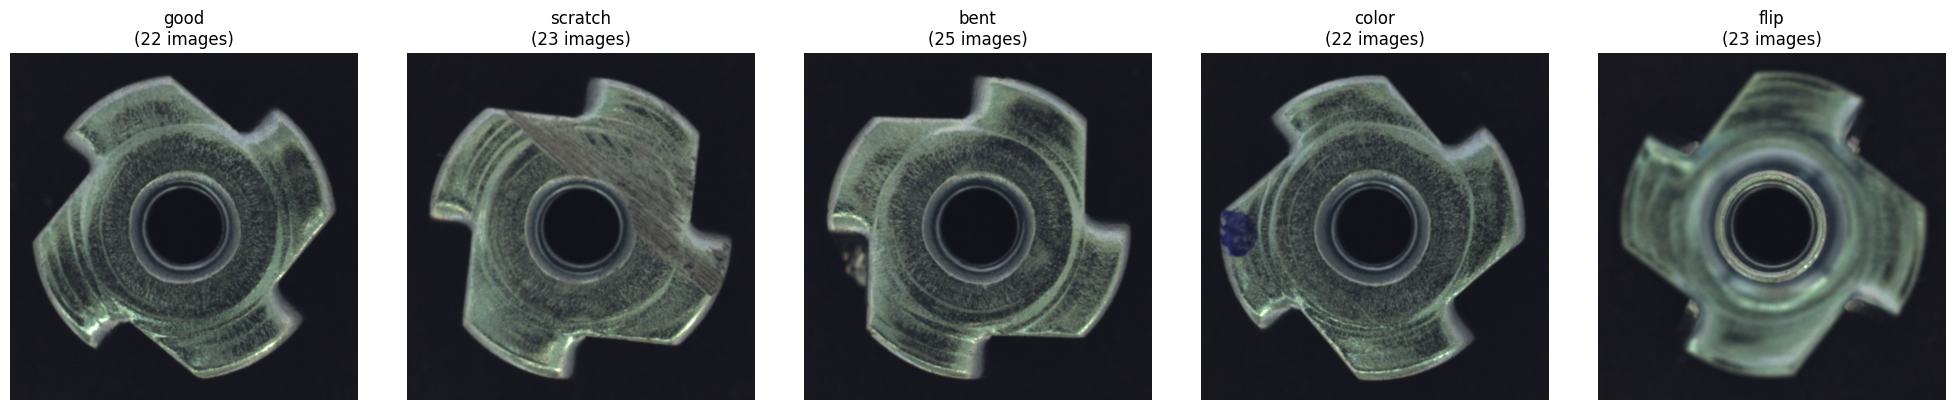


Look at each image above. Notice how 'scratch' and 'bent' are visually distinct
from 'good' - this is what our classifier needs to learn to tell apart.


In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import glob

# base_path reflects whichever download path succeeded above (primary or backup) -
# referencing it directly here avoids re-deriving a path that has already been validated.
print(f"Using base_path: {base_path}")

categories = ['good', 'scratch', 'bent', 'color', 'flip']
fig, axes = plt.subplots(1, len(categories), figsize=(20, 4))

for i, cat in enumerate(categories):
    # Recursive search rather than a fixed path tolerates minor structural differences
    # between the primary and backup download sources.
    matches = glob.glob(f'{base_path}/**/{cat}', recursive=True)
    files = []
    if matches:
        files = sorted(glob.glob(f'{matches[0]}/*.png')) + sorted(glob.glob(f'{matches[0]}/*.jpg'))
    if files:
        img = Image.open(files[0])
        axes[i].imshow(img)
        axes[i].set_title(f'{cat}\n({len(files)} images)')
        axes[i].axis('off')
    else:
        axes[i].set_title(f'{cat}\n(folder not found)')
        axes[i].axis('off')

plt.tight_layout()
plt.savefig('/content/data_overview.png', dpi=100)
plt.show()

print("\nLook at each image above. Notice how 'scratch' and 'bent' are visually distinct")
print("from 'good' - this is what our classifier needs to learn to tell apart.")

## Step 3 — Train/Test Split Construction

**Design decision: binary classification.** The four defect types (scratch, bent, color, flip) are combined into a single "defective" class, framing the problem as binary good/defective classification rather than multi-class defect typing.

This reflects the actual research question under investigation — how much real defective data is required, not how to distinguish defect types from one another — and matches how a pass/fail inspection decision is made on a production floor.

In [ ]:
import random

random.seed(42)  # fixes the split composition so it is reproducible across notebook re-runs

def find_images(category_name):
    """Locates all images inside any folder named `category_name`
    under base_path. Recursive search, rather than a fixed train/test/X path,
    tolerates differences in how the primary and backup download sources
    organize the same underlying MVTec data."""
    folders = glob.glob(f'{base_path}/**/{category_name}', recursive=True)
    images = []
    for folder in folders:
        images += glob.glob(f'{folder}/*.png') + glob.glob(f'{folder}/*.jpg') + glob.glob(f'{folder}/*.jpeg')
    return list(set(images))  # deduplicates in case multiple matched folders overlap

# Good images exist under both train/ and test/ in the source data; both are pooled here
# since the binary classification framing (Step 3 markdown) does not distinguish their origin.
good_images = find_images('good')

# Defective images are pooled across all four defect types, consistent with the binary framing.
defect_images = []
for cat in ['scratch', 'bent', 'color', 'flip']:
    defect_images += find_images(cat)

print(f"Total good images: {len(good_images)}")
print(f"Total defective images: {len(defect_images)}")

assert len(good_images) > 0, "No good images found! Check base_path is correct."
assert len(defect_images) > 0, "No defective images found! Check base_path is correct."
# This threshold catches a previously observed failure mode: if train/good fails to download,
# total good images drops to roughly 22 (test/good only) instead of the expected ~240+
# (train/good + test/good combined), and training silently proceeds on an unrepresentative,
# heavily imbalanced sample. Asserting here surfaces the problem immediately rather than
# allowing it to manifest later as an uninterpretable evaluation result.
assert len(good_images) >= 100, (
    f"Only {len(good_images)} good images found - this is suspiciously low (real MVTec metal_nut "
    f"has ~240 total good images between train+test). This usually means the train/good folder "
    f"(~220 images) failed to download. Go back to Step 2 and check the verification cell output, "
    f"or run the BACKUP METHOD cell."
)

# The held-out test set below is never used in training under any condition in this study.
# Every classifier trained in Notebooks 1 and 3 is evaluated against this exact set.
random.shuffle(defect_images)
random.shuffle(good_images)

n_test_defect = max(20, int(0.3 * len(defect_images)))  # ~30% reserved for testing, floor of 20
n_test_good = max(20, int(0.3 * len(good_images)))

test_defect = defect_images[:n_test_defect]
train_pool_defect = defect_images[n_test_defect:]  # available real-defect pool for Notebook 3's experiments

test_good = good_images[:n_test_good]
train_good = good_images[n_test_good:]

# A train_good/train_pool_defect imbalance is flagged here because it is the specific
# condition previously observed to cause single-class prediction collapse during training.
if len(train_good) < 0.5 * len(train_pool_defect):
    print(f"\nWARNING: train_good ({len(train_good)}) is less than half of train_pool_defect "
          f"({len(train_pool_defect)}). This imbalance can cause the model to collapse to always "
          f"predicting 'defective'. If you see 100% false rejection rate later, come back to this cell.")

print(f"\nHeld-out TEST set: {len(test_good)} good + {len(test_defect)} defective")
print(f"Available for training: {len(train_good)} good + {len(train_pool_defect)} defective")
print("\nThe held-out test set is now FIXED for the rest of this project.")
print("Every model version (baseline, synthetic-only, mixed) gets tested against this exact same set.")

Total good images: 242
Total defective images: 93

Held-out TEST set: 72 good + 27 defective
Available for training: 170 good + 66 defective

The held-out test set is now FIXED for the rest of this project.
Every model version (baseline, synthetic-only, mixed) gets tested against this exact same set.


In [ ]:
import json

# Persisting the split to disk allows Notebooks 2 and 3 to reconstruct it exactly,
# rather than re-deriving it, eliminating any risk of drift between notebook sessions.
split_record = {
    'test_good': test_good,
    'test_defect': test_defect,
    'train_good': train_good,
    'train_pool_defect': train_pool_defect,
}

with open('/content/data_split.json', 'w') as f:
    json.dump(split_record, f, indent=2)

print("Saved data_split.json - download this file and keep it, you'll re-upload it in later notebooks")

Saved data_split.json - download this file and keep it, you'll re-upload it in later notebooks


## Step 4 — Model Definition

**Architecture: ResNet18 via transfer learning.** The final classification layer of an ImageNet-pretrained ResNet18 is replaced with a 2-class output head (good/defective). The pretrained backbone provides general visual feature extraction (edges, textures, shapes); only the final layer is adapted to this specific task.

**Rationale for this architecture choice:**
- Trains efficiently on a free-tier GPU
- A well-characterized standard baseline, which keeps later comparisons interpretable
- A larger architecture would be prone to overfitting given the limited dataset size

In [ ]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")  # confirms GPU availability before committing to training

# Preprocessing matches ResNet's expected input format and ImageNet normalization statistics,
# consistent with the pretrained weights being used.
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class NutDataset(Dataset):
    """Loads images on demand from a list of (filepath, label) pairs."""
    def __init__(self, good_paths, defect_paths, transform):
        self.samples = [(p, 0) for p in good_paths] + [(p, 1) for p in defect_paths]  # label convention: 0=good, 1=defective
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        img = self.transform(img)
        return img, label

def build_model():
    """Returns a freshly initialized ResNet18 with a 2-class output head. Called once per
    training run so every experiment starts from an identical, untrained state."""
    model = models.resnet18(weights='IMAGENET1K_V1')
    model.fc = nn.Linear(model.fc.in_features, 2)  # final layer replaced with a 2-class output
    return model.to(device)

print("Model builder ready.")

Using device: cuda
Model builder ready.


## Step 5 — Training Procedure

Defines the training loop used identically across every classifier trained in this study (baseline here, and all nine conditions in Notebook 3), ensuring that any difference in results reflects only differences in training data, not differences in training procedure.

In [ ]:
def train_model(model, train_loader, epochs=15, lr=0.001):
    """Trains a model for a fixed number of epochs, reporting loss per epoch to confirm convergence."""
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{epochs} - loss: {avg_loss:.4f}")

    return model

print("Training function ready.")

Training function ready.


## Step 6 — Baseline Model Training

Trains the reference classifier on the complete real-data training pool (all four defect types combined into the binary defective class). This baseline result is the comparison point for every subsequent experiment in this study.

In [ ]:
# The baseline uses the full real-data training pool, with no synthetic data and no
# real-data reduction - this is the upper-bound reference condition for the study.
baseline_dataset = NutDataset(train_good, train_pool_defect, transform)
baseline_loader = DataLoader(baseline_dataset, batch_size=8, shuffle=True)

print(f"Training baseline model on {len(train_good)} good + {len(train_pool_defect)} defective real images...")

baseline_model = build_model()
baseline_model = train_model(baseline_model, baseline_loader, epochs=15)

torch.save(baseline_model.state_dict(), '/content/baseline_model.pt')
print("\nBaseline model saved.")

Training baseline model on 170 good + 66 defective real images...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 31.4MB/s]


Epoch 1/15 - loss: 0.6362
Epoch 2/15 - loss: 0.2881
Epoch 3/15 - loss: 0.3753
Epoch 4/15 - loss: 0.1433
Epoch 5/15 - loss: 0.1481
Epoch 6/15 - loss: 0.1286
Epoch 7/15 - loss: 0.1970
Epoch 8/15 - loss: 0.1544
Epoch 9/15 - loss: 0.0434
Epoch 10/15 - loss: 0.0451
Epoch 11/15 - loss: 0.0642
Epoch 12/15 - loss: 0.0571
Epoch 13/15 - loss: 0.0929
Epoch 14/15 - loss: 0.1401
Epoch 15/15 - loss: 0.1286

Baseline model saved.


## Step 7 — Evaluation Metrics

Evaluation is reported using two metrics with direct manufacturing relevance, prioritized over raw accuracy:

**Escape rate** — real defective parts classified as good. The customer-facing risk metric: a defect that escapes inspection reaches the field.

**False rejection rate** — real good parts classified as defective. The cost metric: a false rejection results in unnecessary scrap or rework, but carries no field risk.

In [ ]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score

def evaluate_model(model, good_paths, defect_paths, transform, model_name="model"):
    """Evaluates a model against the fixed held-out test set, returning accuracy alongside
    escape rate and false rejection rate."""
    model.eval()
    test_dataset = NutDataset(good_paths, defect_paths, transform)
    test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    # Confusion matrix layout: rows = actual class, columns = predicted class
    # [[true_good_pred_good,   true_good_pred_defect],
    #  [true_defect_pred_good, true_defect_pred_defect]]
    cm = confusion_matrix(all_labels, all_preds, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    accuracy = accuracy_score(all_labels, all_preds)
    escape_rate = fn / (fn + tp) if (fn + tp) > 0 else 0  # proportion of real defects missed entirely
    false_rejection_rate = fp / (fp + tn) if (fp + tn) > 0 else 0  # proportion of good parts incorrectly flagged

    results = {
        'model_name': model_name,
        'accuracy': round(accuracy, 4),
        'escape_rate': round(escape_rate, 4),
        'false_rejection_rate': round(false_rejection_rate, 4),
        'true_negatives': int(tn),
        'false_positives': int(fp),
        'false_negatives': int(fn),
        'true_positives': int(tp),
    }

    print(f"\n=== {model_name} ===")
    print(f"Accuracy: {accuracy:.2%}")
    print(f"Escape rate (defects missed): {escape_rate:.2%}  <- the dangerous number")
    print(f"False rejection rate (good parts wrongly flagged): {false_rejection_rate:.2%}")

    return results

baseline_results = evaluate_model(baseline_model, test_good, test_defect, transform, model_name="Baseline (100% real)")


=== Baseline (100% real) ===
Accuracy: 84.85%
Escape rate (defects missed): 55.56%  <- the dangerous number
False rejection rate (good parts wrongly flagged): 0.00%


In [ ]:
import json

# Persisted for direct numerical comparison against every condition evaluated in Notebook 3.
with open('/content/baseline_results.json', 'w') as f:
    json.dump(baseline_results, f, indent=2)

print("Saved baseline_results.json")
print("\nDownload these 3 files from the Colab file browser (left sidebar) before closing:")
print("1. data_split.json       <- the fixed train/test split, needed for ALL future notebooks")
print("2. baseline_model.pt      <- the trained baseline model weights")
print("3. baseline_results.json   <- the baseline numbers we compare everything else against")

Saved baseline_results.json

Download these 3 files from the Colab file browser (left sidebar) before closing:
1. data_split.json       <- the fixed train/test split, needed for ALL future notebooks
2. baseline_model.pt      <- the trained baseline model weights
3. baseline_results.json   <- the baseline numbers we compare everything else against


## Summary

- A reproducible, fixed train/test split was established (`data_split.json`), binarized into good/defective classification, and reused without modification throughout the remainder of the study.
- A ResNet18 baseline classifier was trained on the complete real-data training pool, establishing the reference point against which all real/synthetic data mixing conditions in Notebook 3 are compared.
- Baseline reference metrics were recorded: accuracy, escape rate, and false rejection rate (`baseline_results.json`).

**Continuity to Notebook 2.** The next notebook uses a vision-language model to characterize real scratch defects and generate synthetic scratch images via diffusion-based inpainting, guided by those characterizations.